In [55]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec

import requests

import torch

from transformers import AutoTokenizer, AutoModelForCausalLM, logging

logging.set_verbosity_error()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


# Load the GTP2-medium model

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("gpt2-medium")
model = AutoModelForCausalLM.from_pretrained("gpt2-medium").to(device)
model.eval()
num_embed = model.config.n_embd

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

# Import text

In [ ]:
text = requests.get('https://www.gutenberg.org/cache/epub/219/pg219.txt').text # Heart of Darkness
tokens = tokenizer.encode(text,return_tensors='pt')
num_tokens = len(tokens[0])

print(f'There are {num_tokens:,} tokens, {len(np.unique(tokens[0].tolist()))} of which are unique.')

There are 63,991 tokens, 7489 of which are unique.


In [ ]:
internal_tokens = {","}
terminal_tokens = {"."}

punct_tokens = np.zeros(num_tokens, dtype=np.int8)

tok_txt = tokenizer.convert_ids_to_tokens(tokens[0].tolist())

for i in range(400, num_tokens - 1):
    t = tok_txt[i]

    if t in internal_tokens:
        punct_tokens[i] = 1

    elif t in terminal_tokens:
        prev = tok_txt[i - 1]
        nxt  = tok_txt[i + 1]

        # convert_ids_to_tokens gives GPT2 BPE pieces; digits are still digits
        if (prev and prev[-1].isdigit()) or (nxt and nxt[0].isdigit()):
            continue

        punct_tokens[i] = 2

print(f'There are {sum(punct_tokens == 1): 4} internal puctuation tokens and {sum(punct_tokens == 2): 4} terminal punctuation tokens.')

There are  2969 internal puctuation tokens and  2279 terminal punctuation tokens.


In [ ]:
# Find the indices
internal_indices = np.where(punct_tokens == 1)[0]
terminal_indices = np.where(punct_tokens == 2)[0]

# Extract 9 tokens before and after the punctuation tokens
context_win = 9
for i in terminal_indices[:context_win]:
  print(i,':',tokenizer.decode(tokens[0, i - context_win : i + context_win]),'\n')

419 :  of
an interminable waterway. In the offing the sea and the 

485 :  gleams of varnished sprits. A
haze rested on the 

507 :  out to sea in vanishing
flatness. The air was dark above Gravesend, 

549 : gest, and the greatest, town on earth.

The Director of Companies 

564 :  Director of Companies was our captain and our host. We four
affectionately watched 

588 :  the bows looking to
seaward. On the whole river there was nothing that 

604 :  nothing that looked half so
nautical. He resembled a pilot, which to a 

622 :  seaman is trustworthiness
personified. It was difficult to realize his work was 

652 :  but behind him, within the brooding gloom.

Between us there was 



# Create batches and derive activations

In [ ]:
batch_size = 250
context_pre = 20
context_post = 10

batch_internal = torch.zeros((batch_size, context_pre+context_post+1), dtype=torch.long)
batch_terminal = torch.zeros((batch_size, context_pre+context_post+1), dtype=torch.long)

for i in range(batch_size):
  token_loc = internal_indices[i]
  batch_internal[i] = tokens[0, token_loc - context_pre : token_loc + context_post+1]

  token_loc = terminal_indices[i]
  batch_terminal[i] = tokens[0, token_loc - context_pre : token_loc + context_post+1]

batch_internal.shape


torch.Size([250, 31])

In [ ]:
# Pass the batches through the model
with torch.no_grad():
  out_internal = model(batch_internal.to(device), output_hidden_states=True)
  out_terminal = model(batch_terminal.to(device), output_hidden_states=True)


In [ ]:
out_internal.hidden_states[3].shape, len(out_internal.hidden_states)

(torch.Size([250, 31, 1024]), 25)

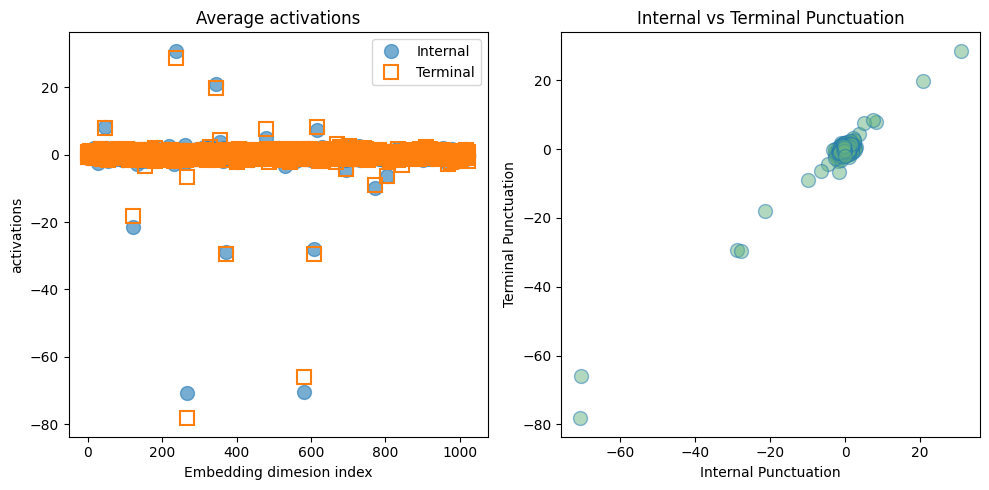

In [ ]:
# Visualize
lst_internal = []
lst_terminal = []

for i in range(len(out_internal.hidden_states)):
  lst_internal.append(out_internal.hidden_states[i].detach().cpu().numpy())
  lst_terminal.append(out_terminal.hidden_states[i].detach().cpu().numpy())


averages_internal = np.mean(lst_internal[3][:,context_pre,:], axis=0)
averages_terminal = np.mean(lst_terminal[3][:,context_pre,:], axis=0)


fig = plt.figure(figsize=(10, 5))
axs = fig.subplot_mosaic([['a','b']])

# Modified plots to make zorder more visible
axs['a'].plot(averages_internal, 'o', label='Internal', zorder=1, ms=10, alpha=0.6)
axs['a'].plot(averages_terminal, 's', label='Terminal', zorder=2, ms=10,
              mfc='none', mec='C1', mew=1.5)
axs['a'].set(xlabel='Embedding dimesion index', ylabel='activations', title='Average activations')
axs['a'].legend()

axs['b'].plot(averages_internal, averages_terminal, 'o', mfc=[.4,.7,.5], ms=10, alpha=.5)
axs['b'].set(xlabel='Internal Punctuation', ylabel='Terminal Punctuation', title='Internal vs Terminal Punctuation')

plt.tight_layout()
plt.show()

# MI and Covariance of activations in hidden layer 1

In [ ]:
# function for Mutual Information
def mi_cov_pair(x, y, outlierthresh=5, nbins=10):
    # standardize
    x = (x - x.mean()) / x.std(ddof=1)
    y = (y - y.mean()) / y.std(ddof=1)

    if outlierthresh > 0:
        m = (np.abs(x) <= outlierthresh) & (np.abs(y) <= outlierthresh)
        x, y = x[m], y[m]

    # MI via 2D histogram
    Z, _, _ = np.histogram2d(x, y, bins=nbins)
    pxy = Z / (Z.sum() + 1e-12)
    px  = pxy.sum(axis=1)
    py  = pxy.sum(axis=0)

    eps = 1e-12
    Hx  = -(px  * np.log2(px  + eps)).sum()
    Hy  = -(py  * np.log2(py  + eps)).sum()
    Hxy = -(pxy * np.log2(pxy + eps)).sum()
    MI  = (Hx + Hy) - Hxy

    C = np.sum((x - x.mean()) * (y - y.mean())) / (len(x) - 1)
    return MI, C


In [ ]:
layeri = 20
X_in = lst_internal[layeri][:, context_pre, :]   # (B, D)
X_tr = lst_terminal[layeri][:, context_pre, :]   # (B, D)

B = X_in.shape[0]
mi_in  = np.zeros((B, B))
mi_tr  = np.zeros((B, B))
cov_in = np.zeros((B, B))
cov_tr = np.zeros((B, B))

# double-loop over the token pairs
for bi in range(B):
    xi_in = X_in[bi]
    xi_tr = X_tr[bi]
    for bj in range(bi + 1, B):
        mi_in[bi, bj],  cov_in[bi, bj]  = mi_cov_pair(xi_in, X_in[bj])
        mi_tr[bi, bj],  cov_tr[bi, bj]  = mi_cov_pair(xi_tr, X_tr[bj])

In [ ]:
# a variable to extract and vectorize the unique matrix elements
unique_indices = np.triu_indices(batch_size,1)
unique_indices

(array([  0,   0,   0, ..., 247, 247, 248]),
 array([  1,   2,   3, ..., 248, 249, 249]))

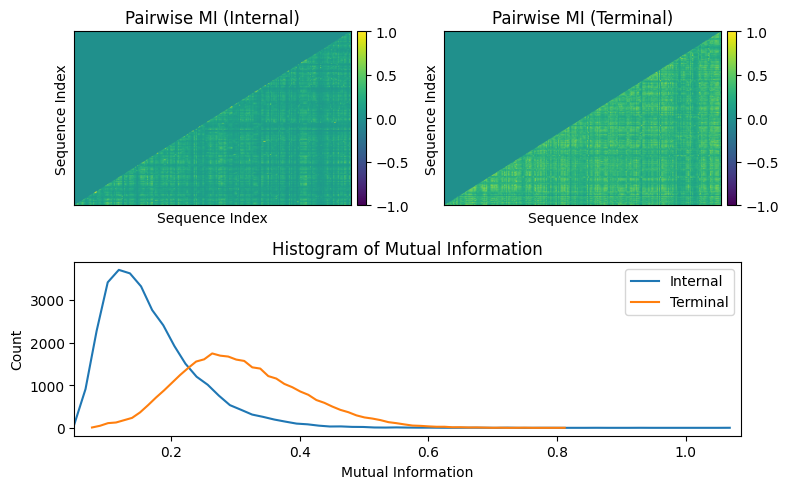

In [ ]:
# Visualize pairwise MI
fig, axs = plt.subplot_mosaic([[1,2],[3,3]], figsize=(8,5))

h = axs[1].imshow(mi_in, cmap='viridis', vmin=-1, vmax=1, origin='lower', aspect='auto')
plt.colorbar(h,ax=axs[1],fraction=.046,pad=.02)
axs[1].set(title='Pairwise MI (Internal)', xticks=[], yticks=[], xlabel='Sequence Index', ylabel='Sequence Index')

h = axs[2].imshow(mi_tr, cmap='viridis', vmin=-1, vmax=1, origin='lower', aspect='auto')
plt.colorbar(h,ax=axs[2],fraction=.046,pad=.02)
axs[2].set(title='Pairwise MI (Terminal)', xticks=[], yticks=[], xlabel='Sequence Index', ylabel='Sequence Index')

# get histograms from nonzero elements
yIntern,xIntern = np.histogram(mi_in[unique_indices],bins=60)
yTermin,xTermin = np.histogram(mi_tr[unique_indices],bins=60)

axs[3].plot(xIntern[:-1],yIntern,label='Internal')
axs[3].plot(xTermin[:-1],yTermin,label='Terminal')
axs[3].set(title='Histogram of Mutual Information', xlabel='Mutual Information',ylabel='Count')
axs[3].set_xlim([min(xIntern[0],xTermin[0]),max(xIntern[-1],xTermin[-1])])
axs[3].legend()

plt.tight_layout()
plt.show()

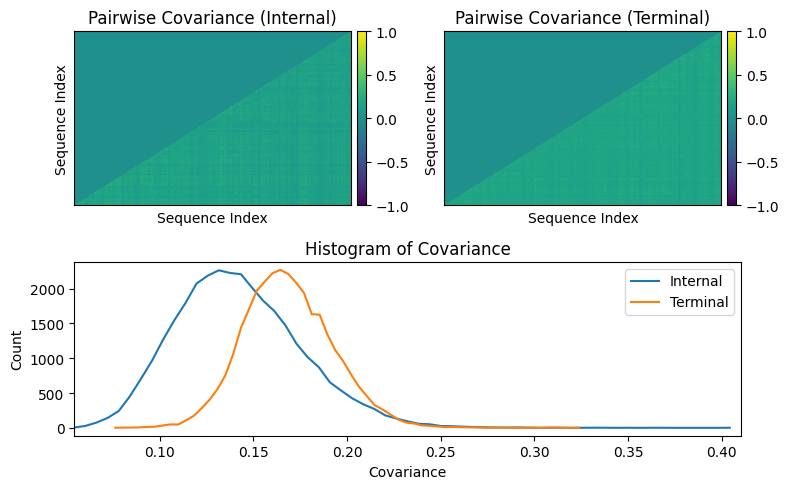

In [ ]:
# Visualize pairwise MI
fig, axs = plt.subplot_mosaic([[1,2],[3,3]], figsize=(8,5))

h = axs[1].imshow(cov_in, cmap='viridis', vmin=-1, vmax=1, origin='lower', aspect='auto')
plt.colorbar(h,ax=axs[1],fraction=.046,pad=.02)
axs[1].set(title='Pairwise Covariance (Internal)', xticks=[], yticks=[], xlabel='Sequence Index', ylabel='Sequence Index')

h = axs[2].imshow(cov_tr, cmap='viridis', vmin=-1, vmax=1, origin='lower', aspect='auto')
plt.colorbar(h,ax=axs[2],fraction=.046,pad=.02)
axs[2].set(title='Pairwise Covariance (Terminal)', xticks=[], yticks=[], xlabel='Sequence Index', ylabel='Sequence Index')

# get histograms from nonzero elements
yIntern,xIntern = np.histogram(cov_in[unique_indices],bins=60)
yTermin,xTermin = np.histogram(cov_tr[unique_indices],bins=60)

axs[3].plot(xIntern[:-1],yIntern,label='Internal')
axs[3].plot(xTermin[:-1],yTermin,label='Terminal')
axs[3].set(title='Histogram of Covariance', xlabel='Covariance',ylabel='Count')
axs[3].set_xlim([min(xIntern[0],xTermin[0]),max(xIntern[-1],xTermin[-1])])
axs[3].legend()

plt.tight_layout()
plt.show()

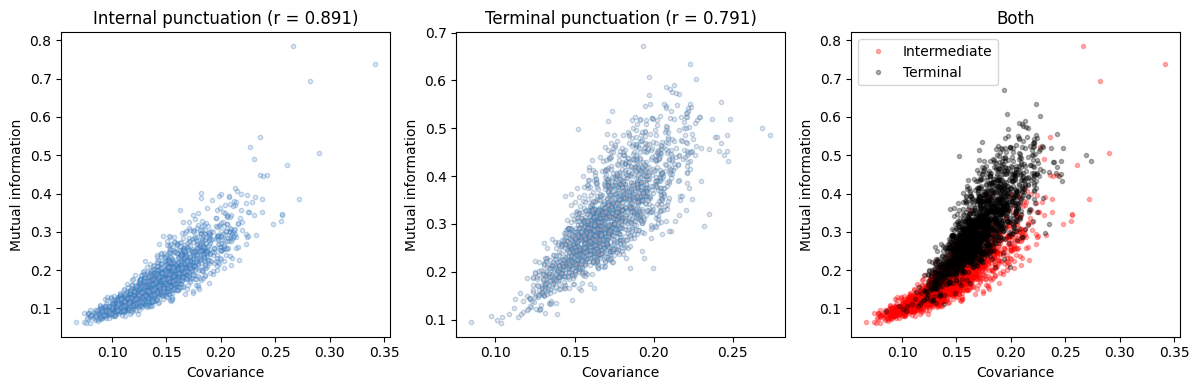

In [ ]:
## covariance by mutual information

_,axs = plt.subplots(1,3,figsize=(12,4))

# skip to facilitate plotting
pnts2skip = 17

# plot the internal punctuations
axs[0].plot(cov_in[unique_indices][::pnts2skip],mi_in[unique_indices][::pnts2skip],'.',mfc=[.7,.7,.9,.3])
axs[0].set(xlabel='Covariance',ylabel='Mutual information',
           title=f'Internal punctuation (r = {np.corrcoef(cov_in[unique_indices],mi_in[unique_indices])[0,1]:.3f})')

# plot the terminal punctuations
axs[1].plot(cov_tr[unique_indices][::pnts2skip],mi_tr[unique_indices][::pnts2skip],'.',mfc=[.9,.7,.7,.3])
axs[1].set(xlabel='Covariance',ylabel='Mutual information',
           title=f'Terminal punctuation (r = {np.corrcoef(cov_tr[unique_indices],mi_tr[unique_indices])[0,1]:.3f})')


axs[2].plot(cov_in[unique_indices][::pnts2skip],mi_in[unique_indices][::pnts2skip],'r.',alpha=.3,label='Intermediate')
axs[2].plot(cov_tr[unique_indices][::pnts2skip],mi_tr[unique_indices][::pnts2skip],'k.',alpha=.3,label='Terminal')
axs[2].set(xlabel='Covariance',ylabel='Mutual information',title='Both')
axs[2].legend()


plt.tight_layout()
plt.show()

# Mutual Information and Covariance for all layers

In [ ]:
B = batch_size
N = len(lst_internal)

mi_in_all  = np.zeros((N, B, B))
mi_tr_all  = np.zeros((N, B, B))
cov_in_all = np.zeros((N, B, B))
cov_tr_all = np.zeros((N, B, B))

# Loop over all layers
for li in range(N):
  X_in = lst_internal[li][:, context_pre, :]   # (B, D)
  X_tr = lst_terminal[li][:, context_pre, :]   # (B, D)

  # loop over the token-pairs
  for bi in range(B):
      xi_in = X_in[bi]
      xi_tr = X_tr[bi]
      for bj in range(bi + 1, B):
          mi_in_all[li, bi, bj],  cov_in_all[li, bi, bj]  = mi_cov_pair(xi_in, X_in[bj])
          mi_tr_all[li, bi, bj],  cov_tr_all[li, bi, bj]  = mi_cov_pair(xi_tr, X_tr[bj])

  print(f'Layer {li} done')

Layer 0 done
Layer 1 done
Layer 2 done
Layer 3 done
Layer 4 done
Layer 5 done
Layer 6 done
Layer 7 done
Layer 8 done
Layer 9 done
Layer 10 done
Layer 11 done
Layer 12 done
Layer 13 done
Layer 14 done
Layer 15 done
Layer 16 done
Layer 17 done
Layer 18 done
Layer 19 done
Layer 20 done
Layer 21 done
Layer 22 done
Layer 23 done
Layer 24 done


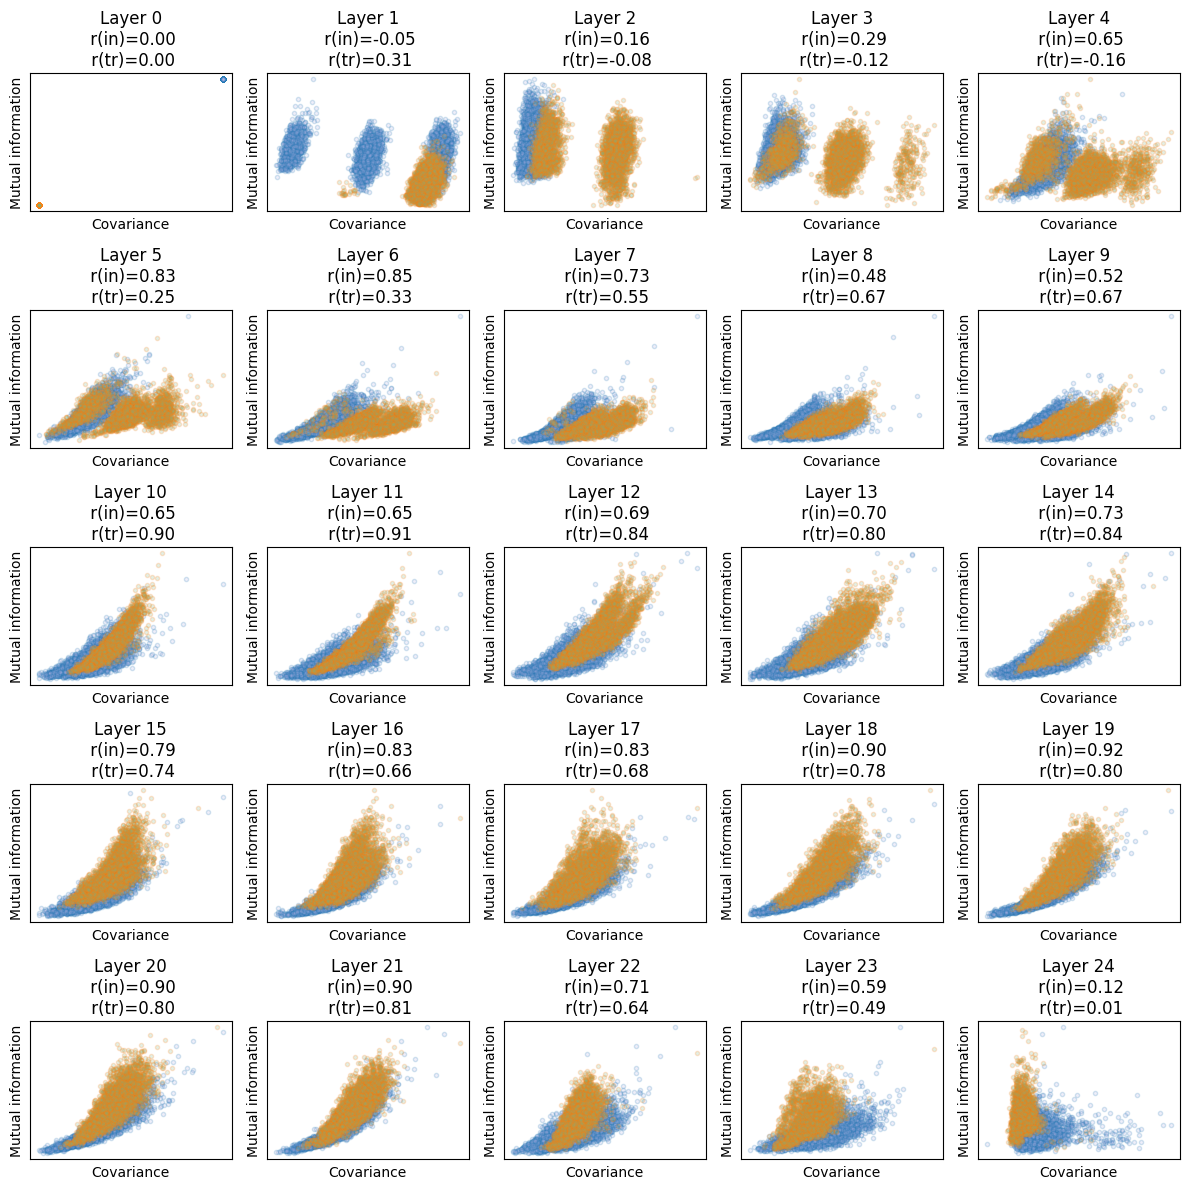

In [ ]:
# Visualize
_, axs = plt.subplots(5,5,figsize=(12,12))
axs = axs.flatten()

# Skip 7 points
pnts2skip = 7

# Loop over all layers
for layeri in range(N):
  cov_in = cov_in_all[layeri][unique_indices][::pnts2skip]
  mi_in  = mi_in_all[layeri][unique_indices][::pnts2skip]
  cov_tr = cov_tr_all[layeri][unique_indices][::pnts2skip]
  mi_tr  = mi_tr_all[layeri][unique_indices][::pnts2skip]

  axs[layeri].plot(cov_in,mi_in,'.',mfc=[.7,.7,.9,.2])
  axs[layeri].plot(cov_tr,mi_tr,'.',mfc=[.5,.7,.5,.2])

  if layeri == 0:
    r_in = 0
    r_tr = 0
  else:
    r_in = np.corrcoef(cov_in, mi_in)[0,1]
    r_tr = np.corrcoef(cov_tr, mi_tr)[0,1]

  axs[layeri].set(xlabel='Covariance',ylabel='Mutual information',xticks=[], yticks=[],title=f'Layer {layeri}\n r(in)={r_in:.2f}\n r(tr)={r_tr:.2f}')

plt.tight_layout()
plt.show()

# Identify cluster memberships

In [46]:
from sklearn.cluster import KMeans

layeri = 2
X = lst_internal[layeri][:, context_pre, :]
labels = KMeans(n_clusters=3, random_state=0).fit_predict(X)

In [47]:
# Inspect actual text contexts
for k in range(3):
    print(f"\nCluster {k}:")
    idx = np.where(labels == k)[0][:5]
    for i in idx:
        print(tokenizer.decode(batch_internal[i]))


Cluster 0:
zen-mast. He had
sunken cheeks, a yellow complexion, a straight back, an ascetic aspect,
and, with
 had
sunken cheeks, a yellow complexion, a straight back, an ascetic aspect,
and, with his arms dropped, the
unken cheeks, a yellow complexion, a straight back, an ascetic aspect,
and, with his arms dropped, the palms of hands out
 yellow complexion, a straight back, an ascetic aspect,
and, with his arms dropped, the palms of hands outwards, resembled an
 his arms dropped, the palms of hands outwards, resembled an
idol. The director, satisfied the anchor had good hold, made his way

Cluster 1:
 to realize his work was not out there in
the luminous estuary, but behind him, within the brooding gloom.


 bond of the
sea. Besides holding our hearts together through long periods of
separation, it had the effect of making us tolerant of each

yarns—and even convictions. The Lawyer—the best of old fellows—had,
because of his many years and many virtues
yer—the best of old fellows—had

# Plot MI and covariance by layers

In [ ]:
def safe_hist(x, bins):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.zeros(len(bins)-1), bins
    return np.histogram(x, bins=bins, density=True)

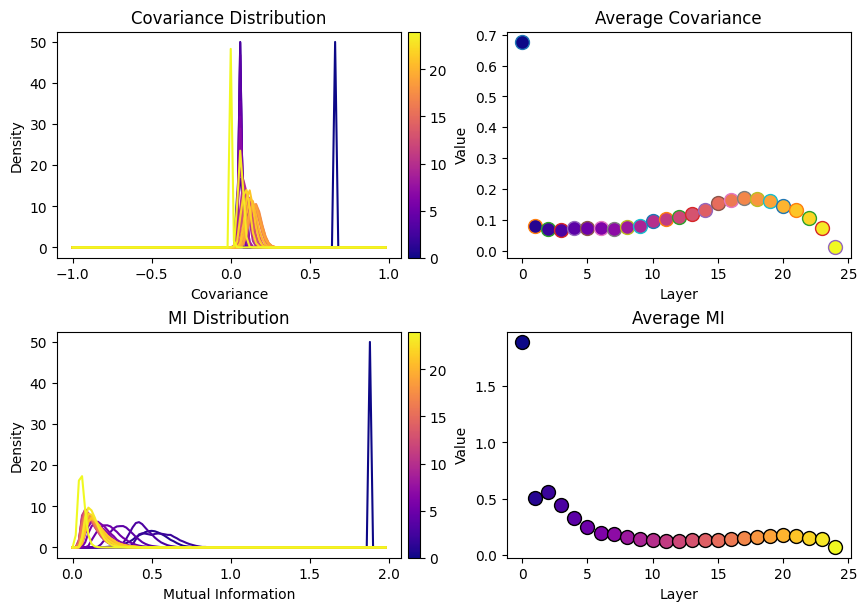

In [75]:
fig = plt.figure(figsize=(12,6),constrained_layout=True)

gs = GridSpec(2,3, figure=fig)

ax00 = fig.add_subplot(gs[0,0])
ax01 = fig.add_subplot(gs[0,1])
ax10 = fig.add_subplot(gs[1,0])
ax11 = fig.add_subplot(gs[1,1])


norm = mpl.colors.Normalize(vmin=0, vmax=len(lst_internal)-1)
cmap = mpl.cm.plasma

vals = cov_in_all[layeri][unique_indices]
vals = vals[np.isfinite(vals)]

c_min, c_max = vals.mean(), vals.max()

vals = mi_in_all[layeri][unique_indices]
vals = vals[np.isfinite(vals)]

mi_min, mi_max = vals.min(), vals.max()

# bins_cov = np.linspace(c_min, c_max, 101)
# bins_mi  = np.linspace(mi_min, mi_max, 101)
bins_cov = np.linspace(-1, 1, 101)
bins_mi  = np.linspace(0, 2, 101)


for layeri in range(len(lst_internal)):

  c = cmap(norm(layeri))

  yy, xx = safe_hist(cov_in_all[layeri][unique_indices], bins=bins_cov)
  ax00.plot(xx[:-1],yy,c=c)
  ax01.plot(layeri,cov_in_all[layeri][unique_indices].mean(),ms=10,mfc=c,marker='o')

  yy, xx = safe_hist(mi_in_all[layeri][unique_indices], bins=bins_mi)
  ax10.plot(xx[:-1],yy,c=c)
  ax11.plot(layeri,mi_in_all[layeri][unique_indices].mean(), marker='o', ms=10, mfc=c,mec='k')

# Create ScalarMappable
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

plt.colorbar(sm, ax=ax00, pad=.02)
plt.colorbar(sm, ax=ax10, pad=.02)


ax00.set(xlabel='Covariance',ylabel='Density',title='Covariance Distribution')
ax01.set(xlabel='Layer',ylabel='Value',title='Average Covariance')
ax10.set(xlabel='Mutual Information',ylabel='Density',title='MI Distribution')
ax11.set(xlabel='Layer',ylabel='Value',title='Average MI')

# plt.tight_layout()
plt.show()

In [76]:
model

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1024)
    (wpe): Embedding(1024, 1024)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-23): 24 x GPT2Block(
        (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=3072, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=1024)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=4096, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=4096)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=1024, out_features=50257, bias=False)
)